# EDA Datos IBM Transactions for Anti Money Laundering (AML)

## 1. Carga del dataset

Dataset: **AMLworld HI-Small** (IBM Research / ETH Zurich), publicado en Kaggle
bajo licencia CDLA-Sharing-1.0. Referencia: Altman et al. (2023), *Realistic
Synthetic Financial Transactions for Anti-Money Laundering Models*, NeurIPS
Datasets & Benchmarks Track (arXiv:2306.16424).

Versión descargada: v8 (julio de 2025). Esta versión difiere de la reportada en
la Tabla 4 del artículo original — ver sección de discrepancias más abajo.

In [ ]:
from pathlib import Path
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent
DATA_FOLDER = ROOT / 'data'
TEST_FILE_NAME = 'HI-Small_Trans.csv'


comp_data = pd.read_csv(DATA_FOLDER / 'raw' / TEST_FILE_NAME)

comp_data.columns.to_list()


['Timestamp',
 'From Bank',
 'Account',
 'To Bank',
 'Account.1',
 'Amount Received',
 'Receiving Currency',
 'Amount Paid',
 'Payment Currency',
 'Payment Format',
 'Is Laundering']

In [ ]:
df = pd.DataFrame(comp_data)
df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
1,2022-09-01 00:00:00,1420,8005DFEB0,1420,8005DFEB0,897.37,US Dollar,897.37,US Dollar,Reinvestment,0
2,2022-09-01 00:00:00,10,8000F6850,10,8000F6850,99986.94,US Dollar,99986.94,US Dollar,Reinvestment,0
3,2022-09-01 00:00:00,12,8001167D0,12,8001167D0,16.08,US Dollar,16.08,US Dollar,Reinvestment,0
4,2022-09-01 00:00:00,1,8001364A0,1,8001364A0,10.30,US Dollar,10.30,US Dollar,Reinvestment,0
...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022-09-18 10:02:00,9371,8043A0FB0,16163,802F78670,3749.14,US Dollar,3749.14,US Dollar,ACH,1
5078341,2022-09-18 11:18:00,9371,8043A0FB0,9371,8043A0FB0,1785.27,Euro,2091.95,US Dollar,ACH,0
5078342,2022-09-18 11:18:00,9371,8043A0FB0,13858,8095526B0,1785.27,Euro,1785.27,Euro,ACH,1
5078343,2022-09-18 12:58:00,9371,8043A0FB0,1124,8026687E0,2154.54,US Dollar,2154.54,US Dollar,ACH,1


Las 11 columnas corresponden a: marca temporal, banco y cuenta de origen, banco
y cuenta de destino, importes y divisas (de pago y de cobro), formato de pago, y
la etiqueta binaria de blanqueo.

Analizamos el contenido del DataSet por completo. Puntos clave a recoger:
1. Num transacciones (Cuentas únicas).
2. El dato más relevante --> cuantas de estas transacciones son ilícitas.
3. Distribución de los importes. ¿Difiere entre ilícitas y lícitas?
4. Cuantas transacciones tiene cada cuenta.
5. Rango temporal.
6. Formas de pago y divisas.

1. Num transacciones (Cuentas únicas).

In [437]:

# El número total de transacciones es 5078345
print(df.shape)

# Analizamos el número total de cuentas únicas (tanto Account como Account.1)
print("Número de cuentas únicas en la columna 'Account':", df['Account'].nunique())
print("Número de cuentas únicas en la columna 'Account.1':", df['Account.1'].nunique())

accounts = pd.concat([df['Account'], df['Account.1']]).unique()
accounts.shape

print("Número total de cuentas únicas (combinando 'Account' y 'Account.1'):", accounts.shape[0])

(5078345, 11)
Número de cuentas únicas en la columna 'Account': 496995
Número de cuentas únicas en la columna 'Account.1': 420636
Número total de cuentas únicas (combinando 'Account' y 'Account.1'): 515080


### 1.1 Dimensiones y cuentas

El dataset contiene 5.078.345 transacciones. Las cuentas que aparecen como
origen (496.995) y como destino (420.636) suman 917.631, muy por encima del
total de cuentas únicas (515.080). Este solapamiento confirma que la mayoría de
cuentas participan en ambos roles, por lo que el grafo resultante no es
**bipartito**.

2. Número de transacciones ilícitas.

In [438]:
ilicitas = df[df['Is Laundering'] == 1]
print(ilicitas.shape[0])

per_ilicitas = (ilicitas.shape[0] / df.shape[0]) * 100
print(f"Porcentaje de transacciones ilícitas: {per_ilicitas:.4f}%")

5177
Porcentaje de transacciones ilícitas: 0.1019%


In [439]:
df['Is Laundering'].value_counts(normalize=True) * 100

Is Laundering
0    99.898057
1     0.101943
Name: proportion, dtype: float64

Vemos el número de monedas o métodos de transacción que se tiene en todo el dataset

In [440]:
print(df['Payment Currency'].unique())

print(df['Payment Currency'].value_counts(normalize=True) * 100)

<StringArray>
[        'US Dollar',           'Bitcoin',              'Euro',
 'Australian Dollar',              'Yuan',             'Rupee',
               'Yen',      'Mexican Peso',          'UK Pound',
             'Ruble',   'Canadian Dollar',       'Swiss Franc',
       'Brazil Real',       'Saudi Riyal',            'Shekel']
Length: 15, dtype: str
Payment Currency
US Dollar            37.318693
Euro                 23.005467
Swiss Franc           4.624735
Yuan                  4.209088
Shekel                3.784383
Rupee                 3.745354
UK Pound              3.558994
Yen                   3.056291
Ruble                 3.055681
Bitcoin               2.876252
Canadian Dollar       2.757631
Australian Dollar     2.693181
Mexican Peso          2.169191
Saudi Riyal           1.752815
Brazil Real           1.392245
Name: proportion, dtype: float64


In [441]:
print(df['Payment Format'].unique())
print(df['Payment Format'].value_counts(normalize=True) * 100)

<StringArray>
['Reinvestment', 'Cheque', 'Credit Card', 'ACH', 'Cash', 'Wire', 'Bitcoin']
Length: 7, dtype: str
Payment Format
Cheque          36.711389
Credit Card     26.058174
ACH             11.830567
Cash             9.666358
Reinvestment     9.472692
Wire             3.384075
Bitcoin          2.876744
Name: proportion, dtype: float64


### 1.4 Tipos de cambio

In [442]:
data_euro_pay = df[df['Payment Currency'] == 'Euro']

data_euro_pay_dol_rec = data_euro_pay[data_euro_pay['Receiving Currency'] == 'US Dollar'].copy()

data_euro_pay_dol_rec

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
18259,2022/09/01 00:05,13554,801E8C270,13554,801E8C270,15054.33,US Dollar,12847.37,Euro,ACH,0
18261,2022/09/01 00:11,13554,801E8C270,13554,801E8C270,4102.77,US Dollar,3501.30,Euro,ACH,0
19610,2022/09/01 00:22,12,8007DDDF0,12,8007DDDF0,9808.85,US Dollar,8370.87,Euro,ACH,0
19612,2022/09/01 00:25,12,8007DDDF0,12,8007DDDF0,2061.08,US Dollar,1758.93,Euro,ACH,0
19614,2022/09/01 00:12,12,8007DDDF0,12,8007DDDF0,116.28,US Dollar,99.23,Euro,ACH,0
...,...,...,...,...,...,...,...,...,...,...,...
5070998,2022/09/10 23:24,24811,801BD53B0,24811,801BD53B0,940.56,US Dollar,802.67,Euro,ACH,0
5071458,2022/09/10 23:06,12513,8014028B0,12513,8014028B0,16256.19,US Dollar,13873.04,Euro,ACH,0
5071460,2022/09/10 23:07,12513,8014028B0,12513,8014028B0,3582.98,US Dollar,3057.71,Euro,ACH,0
5071462,2022/09/10 23:10,12513,8014028B0,12513,8014028B0,10383.16,US Dollar,8860.99,Euro,ACH,0


In [443]:
data_euro_pay_dol_rec['ratio'] = data_euro_pay_dol_rec['Amount Received']/data_euro_pay_dol_rec['Amount Paid']

data_euro_pay_dol_rec

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,ratio
18259,2022/09/01 00:05,13554,801E8C270,13554,801E8C270,15054.33,US Dollar,12847.37,Euro,ACH,0,1.171783
18261,2022/09/01 00:11,13554,801E8C270,13554,801E8C270,4102.77,US Dollar,3501.30,Euro,ACH,0,1.171785
19610,2022/09/01 00:22,12,8007DDDF0,12,8007DDDF0,9808.85,US Dollar,8370.87,Euro,ACH,0,1.171784
19612,2022/09/01 00:25,12,8007DDDF0,12,8007DDDF0,2061.08,US Dollar,1758.93,Euro,ACH,0,1.171781
19614,2022/09/01 00:12,12,8007DDDF0,12,8007DDDF0,116.28,US Dollar,99.23,Euro,ACH,0,1.171823
...,...,...,...,...,...,...,...,...,...,...,...,...
5070998,2022/09/10 23:24,24811,801BD53B0,24811,801BD53B0,940.56,US Dollar,802.67,Euro,ACH,0,1.171789
5071458,2022/09/10 23:06,12513,8014028B0,12513,8014028B0,16256.19,US Dollar,13873.04,Euro,ACH,0,1.171783
5071460,2022/09/10 23:07,12513,8014028B0,12513,8014028B0,3582.98,US Dollar,3057.71,Euro,ACH,0,1.171785
5071462,2022/09/10 23:10,12513,8014028B0,12513,8014028B0,10383.16,US Dollar,8860.99,Euro,ACH,0,1.171783


In [444]:
data_euro_pay_dol_rec['ratio'].round(5).unique()

array([1.17178, 1.17182, 1.1718 , 1.17184, 1.17177, 1.17179, 1.17159,
       1.17183, 1.17155, 1.1722 , 1.16944, 1.17157, 1.17194, 1.17176,
       1.17147, 1.17101, 1.17186, 1.17138, 1.17132, 1.17235, 1.1717 ,
       1.17175, 1.17198, 1.17174, 1.17173, 1.17171, 1.1725 , 1.17185,
       1.17162, 1.17219, 1.17181, 1.17188, 1.17096, 1.17163, 1.17172,
       1.17187, 1.17237, 1.17169, 1.17156, 1.17161, 1.17144, 1.1719 ,
       1.17166, 1.17248, 1.1721 , 1.17208, 1.17192, 1.17168, 1.1714 ,
       1.17112, 1.15385, 1.17145, 1.17164, 1.17146, 1.17204, 1.17201,
       1.17214, 1.14286, 1.2    , 1.1715 , 1.17167, 1.17229, 1.17152,
       1.17158, 1.16875, 1.17284, 1.17287, 1.17196, 1.17111, 1.17216,
       1.17082, 1.17135, 1.17368, 1.171  , 1.17407, 1.17191, 1.17203,
       1.17241, 1.17949, 1.16964, 1.17199, 1.17143, 1.17089, 1.17189,
       1.1709 , 1.17544, 1.17113, 1.17079, 1.17391, 1.17371, 1.17211,
       1.172  , 1.17708, 1.17434, 1.17308, 1.17124, 1.17103, 1.17218,
       1.17073, 1.17

In [445]:
data_euro_pay_dol_rec['ratio'].describe()

count    11060.000000
mean         1.171788
std          0.001088
min          1.142857
25%          1.171781
50%          1.171783
75%          1.171785
max          1.200000
Name: ratio, dtype: float64

In [446]:
df['ratio'] = df['Amount Received']/df['Amount Paid']

df.groupby(['Payment Currency', 'Receiving Currency'])['ratio'].describe()

count       mean           std  \
Payment Currency  Receiving Currency                                      
Australian Dollar Australian Dollar   136478.0   1.000000  0.000000e+00   
                  Bitcoin                  9.0   0.000060  1.177033e-09   
                  Canadian Dollar          3.0   0.933682  2.371182e-04   
                  Euro                    59.0   0.604033  1.212144e-04   
                  Mexican Peso             3.0  14.965339  4.164007e-05   
...                                        ...        ...           ...   
Yuan              Swiss Franc            275.0   0.136620  2.142636e-05   
                  UK Pound               410.0   0.115574  8.416190e-05   
                  US Dollar             6675.0   0.149331  1.985742e-03   
                  Yen                    194.0  15.730604  8.881000e-02   
                  Yuan                203522.0   1.000000  0.000000e+00   

                                            min        25%        50%  \
Payment Currency  Receiving Currency                                    
Australian Dollar Australian Dollar    1.000000   1.000000   1.000000   
                  Bitcoin              0.000060   0.000060   0.000060   
                  Canadian Dollar      0.933409   0.933614   0.933819   
                  Euro                 0.603448   0.604044   0.604049   
                  Mexican Peso        14.965315  14.965315  14.965315   
...                                         ...        ...        ...   
Yuan              Swiss Franc          0.136551   0.136616   0.136616   
                  UK Pound             0.115132   0.115589   0.115593   
                  US Dollar            0.133333   0.149305   0.149307   
                  Yen                 14.500000  15.736980  15.736980   
                  Yuan                 1.000000   1.000000   1.000000   

                                            75%        max  
Payment Currency  Receiving Currency                        
Australian Dollar Australian Dollar    1.000000   1.000000  
                  Bitcoin              0.000060   0.000060  
                  Canadian Dollar      0.933819   0.933819  
                  Euro                 0.604050   0.604459  
                  Mexican Peso        14.965351  14.965388  
...                                         ...        ...  
Yuan              Swiss Franc          0.136618   0.136691  
                  UK Pound             0.115594   0.115666  
                  US Dollar            0.149309   0.250000  
                  Yen                 15.736981  15.737207  
                  Yuan                 1.000000   1.000000  

[216 rows x 8 columns]

In [447]:
df['Cambio_Div'] = df['Payment Currency'] != df['Receiving Currency']
cambio = df[df['Cambio_Div']]

tipos_disp = (cambio
              .groupby(['Payment Currency', 'Receiving Currency'])['ratio']
              .agg(['count', 'mean', 'median', 'std']))

tipos_disp['cv'] = tipos_disp['std'] / tipos_disp['mean']

print("Pares con cambio de divisa:", len(tipos_disp))
print("Pares con una sola observación (cv no calculable):", tipos_disp['cv'].isna().sum())
print()
print(tipos_disp['cv'].describe())

Pares con cambio de divisa: 201
Pares con una sola observación (cv no calculable): 17

count    184.000000
mean       0.011171
std        0.035067
min        0.000000
25%        0.000018
50%        0.000157
75%        0.002586
max        0.263667
Name: cv, dtype: float64


In [448]:
# Pares con mayor dispersión relativa
print(tipos_disp.sort_values('cv', ascending=False).head(10))
print()

# Cuántos pares quedan por debajo del 1 % de variación
print("Pares con cv < 1%:", (tipos_disp['cv'] < 0.01).sum(),
      "de", tipos_disp['cv'].notna().sum())
print()

# Los pares con pocas observaciones no son evidencia fiable: se separan
fiables = tipos_disp[tipos_disp['count'] >= 30]
print("Pares con al menos 30 observaciones:", len(fiables))
print(fiables['cv'].describe())
print()
print("Transacciones en pares descartados:",
      tipos_disp.loc[tipos_disp['count'] < 30, 'count'].sum(),
      "de", tipos_disp['count'].sum())

                                     count          mean        median  \
Payment Currency Receiving Currency                                      
Mexican Peso     Bitcoin                17  5.108192e-06  3.980616e-06   
Bitcoin          Yen                     7  1.166455e+06  1.252343e+06   
Saudi Riyal      Yuan                    8  1.687316e+00  1.785505e+00   
Shekel           Mexican Peso            6  5.884275e+00  6.260900e+00   
Mexican Peso     Yen                     9  5.208942e+00  4.985077e+00   
Yuan             Bitcoin               140  1.369088e-05  1.428571e-05   
US Dollar        Bitcoin              1496  8.561127e-05  8.421476e-05   
Yen              Brazil Real             7  5.141253e-02  5.357207e-02   
Shekel           US Dollar              47  3.014907e-01  2.961207e-01   
Ruble            US Dollar             170  1.291073e-02  1.285276e-02   

                                               std        cv  
Payment Currency Receiving Currency             

In [449]:
# Diagnóstico del par con mayor dispersión entre los fiables
par = cambio[(cambio['Payment Currency'] == 'US Dollar') &
             (cambio['Receiving Currency'] == 'Bitcoin')].copy()

# (a) ¿La dispersión depende del tamaño de la transacción?
corte = par['Amount Paid'].median()
for etiqueta, sub in [('importes pequeños', par[par['Amount Paid'] <= corte]),
                      ('importes grandes',  par[par['Amount Paid'] >  corte])]:
    print(f"{etiqueta:20s} n={len(sub):5d}  cv={sub['ratio'].std()/sub['ratio'].mean():.6f}")

# (b) ¿El tipo deriva a lo largo del periodo?
par['dia'] = pd.to_datetime(par['Timestamp'], format='%Y/%m/%d %H:%M').dt.date
print()
print(par.groupby('dia')['ratio'].agg(['count', 'median']))

importes pequeños    n=  788  cv=0.165634
importes grandes     n=  708  cv=0.011430

            count    median
dia                        
2022-09-01    204  0.000084
2022-09-02    235  0.000084
2022-09-03     70  0.000084
2022-09-04     70  0.000084
2022-09-05    161  0.000084
2022-09-06    161  0.000084
2022-09-07    161  0.000084
2022-09-08    161  0.000084
2022-09-09    203  0.000084
2022-09-10     70  0.000084


**Resultado.** El coeficiente de variación del tipo de cambio — desviación típica
dividida por la media, adimensional y por tanto comparable entre pares de distinta
escala — se calcula sobre los 201 pares de divisas distintas presentes en el
conjunto. De ellos, 17 cuentan con una única observación y la dispersión no es
calculable; los 184 restantes presentan una mediana de 1,6×10⁻⁴ (0,016 %) y un
percentil 75 de 2,6×10⁻³ (0,26 %).

Restringiendo a los [RELLENAR N] pares con al menos 30 observaciones, que
concentran el 98,9 % de las transacciones con cambio de divisa — quedan fuera 820
de 72.170, un 0,016 % del conjunto completo —, el coeficiente de variación máximo
es del 12,4 %.

**Origen de la dispersión residual.** Los pares de mayor variación son aquellos en
los que las dos divisas tienen valores unitarios muy dispares: pagos en dólar o
yuan con cobro en bitcoin, y pagos en shekel o rublo con cobro en dólar. En todos
ellos el importe de destino resulta de multiplicar por un factor muy pequeño o muy
grande, de modo que el redondeo a un número fijo de decimales introduce un error
relativo apreciable en las transacciones de poca cuantía.

La explicación se verifica sobre el par de mayor dispersión con suficientes
observaciones (Dólar → Bitcoin, 1.496 transacciones): dividiendo por la mediana del
importe pagado, el coeficiente de variación es de 0,166 en la mitad de menor
cuantía y de 0,011 en la mitad de mayor cuantía, una reducción de un factor 14,5.
La dispersión es por tanto atribuible al redondeo y no a variabilidad del tipo.

**Ausencia de deriva temporal.** La prueba decisiva es la evolución del tipo a lo
largo del periodo, dado que un tipo variable produciría una tendencia mientras que
el redondeo produce ruido sin estructura temporal. La mediana diaria del ratio en
ese mismo par permanece constante durante los diez días con observaciones, con una
variación relativa entre días de [RELLENAR].

**Nota sobre la métrica.** La desviación típica en términos absolutos no es
comparable entre pares, porque los ratios abarcan varios órdenes de magnitud: de
5×10⁻⁶ en Peso mexicano → Bitcoin a 1,2×10⁶ en Bitcoin → Yen. El valor máximo
observado, 2,3×10⁵, corresponde a este último par y refleja únicamente la magnitud
del ratio, no su variabilidad: su coeficiente de variación es del 19,5 % sobre
siete observaciones.

**Conclusión.** Los resultados son consistentes con el uso de tipos de cambio fijos
por parte del simulador durante todo el periodo, lo que permite normalizar los
importes a una divisa común sin introducir distorsión temporal. Esta característica
no está documentada en el artículo original.

A continuación se analiza si las transacciones ilícitas presentan mayor propensión
al cambio de divisa.

In [450]:
ilicitas = df[df['Is Laundering'] == 1]
ilicitas

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,ratio,Cambio_Div
4742,2022/09/01 00:21,70,100428660,1124,800825340,389769.39,US Dollar,389769.39,US Dollar,Cheque,1,1.0,False
40621,2022/09/01 00:03,70,100428660,11474,805B716C0,29024.33,US Dollar,29024.33,US Dollar,Credit Card,1,1.0,False
69152,2022/09/01 00:01,70,100428660,15980,80B39E7B0,792.92,US Dollar,792.92,US Dollar,Credit Card,1,1.0,False
85763,2022/09/01 00:03,70,100428660,113798,80DC756E0,13171425.53,US Dollar,13171425.53,US Dollar,Cheque,1,1.0,False
90684,2022/09/01 00:23,70,100428660,32375,80E480620,14288.83,US Dollar,14288.83,US Dollar,Cash,1,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5071168,2022/09/10 23:29,111433,8065C2380,21550,8065C69E0,7773.42,US Dollar,7773.42,US Dollar,ACH,1,1.0,False
5073375,2022/09/10 23:07,9,80727F930,219557,8072A28C0,448920.65,Ruble,448920.65,Ruble,Cheque,1,1.0,False
5074248,2022/09/12 03:34,222,812D127D0,50202,812D129C0,20085.71,Saudi Riyal,20085.71,Saudi Riyal,ACH,1,1.0,False
5075056,2022/09/10 23:43,17327,8095F6C20,15695,8095F6C70,3314.36,US Dollar,3314.36,US Dollar,ACH,1,1.0,False


In [451]:
ilicitas_cambio_div = ilicitas[ilicitas['Cambio_Div'] == True]

ilicitas_cambio_div.shape[0]

0

In [452]:
df['Cambio_Div'].sum()

np.int64(72170)

                   count          mean           std       min      25%  \
Is Laundering                                                             
0              5073168.0  3.460309e+05  2.323341e+07  0.000095   158.00   
1                 5177.0  5.169484e+06  2.313315e+08  0.386689  2160.56   

                       50%           75%           max  
Is Laundering                                           
0               891.050000   5273.833138  2.655861e+10  
1              5878.806327  13758.502860  1.629704e+10  


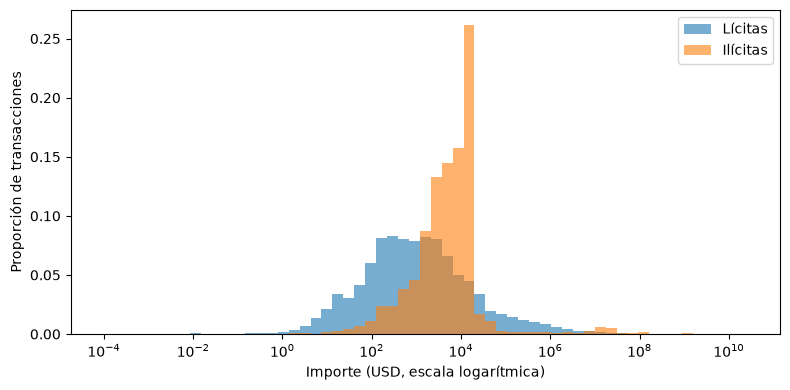

In [ ]:
# 1. Tabla de tipos de cambio a USD (desde las filas que cambian de divisa)
tipos = (df[df['Cambio_Div']]
         .groupby(['Payment Currency', 'Receiving Currency'])['ratio']
         .median())

a_usd = {}
for (origen, destino), r in tipos.items():
    if destino == 'US Dollar':
        a_usd[origen] = r
a_usd['US Dollar'] = 1.0

assert len(a_usd) == df['Payment Currency'].nunique(), \
    f"faltan divisas en a_usd: {set(df['Payment Currency'].unique()) - set(a_usd)}"

# 2. Importe normalizado a dólares
df['amount_usd'] = df['Amount Paid'] * df['Payment Currency'].map(a_usd)

# 3. Comparación numérica
print(df.groupby('Is Laundering')['amount_usd'].describe())

# 4. Histograma en escala logarítmica


fig, ax = plt.subplots(figsize=(8, 4))

# Los bins deben cubrir el rango real de los datos, no un rango fijo:
# con logspace(0, 8) se descartaban en silencio los importes < 1 $ y > 1e8 $.
todos = df['amount_usd'].dropna()
bins = np.logspace(np.log10(todos.min()), np.log10(todos.max()), 60)

for etiqueta, nombre in [(0, 'Lícitas'), (1, 'Ilícitas')]:
    datos = df.loc[df['Is Laundering'] == etiqueta, 'amount_usd'].dropna()
    # Se normaliza con weights y no con density=True: con bins logarítmicos,
    # density divide por la anchura lineal del bin, lo que infla artificialmente
    # la parte izquierda del gráfico en varios órdenes de magnitud.
    ax.hist(datos, bins=bins, alpha=0.6, label=nombre,
            weights=np.ones(len(datos)) / len(datos))

ax.set_xscale('log')
ax.set_xlabel('Importe (USD, escala logarítmica)')
ax.set_ylabel('Proporción de transacciones')
ax.legend()
fig.tight_layout()
fig.savefig(ROOT / 'results' / 'figures' / 'importes_por_clase.png', dpi=150)
plt.show()

assert df['amount_usd'].isna().sum() == 0, "hay importes sin convertir a dólares"

In [454]:
coh = tipos_disp.reset_index()      # pasa las divisas de índice a columnas normales

# Precio en dólares de la divisa de pago y de la de cobro, fila por fila
precio_pago  = coh['Payment Currency'].map(a_usd)
precio_cobro = coh['Receiving Currency'].map(a_usd)

coh['predicho']  = precio_pago / precio_cobro
coh['error_rel'] = (coh['predicho'] - coh['median']).abs() / coh['median']

print(coh['error_rel'].describe())
print()
print("Error relativo máximo:", coh['error_rel'].max())
print()
print(coh.sort_values('error_rel', ascending=False)
         [['Payment Currency', 'Receiving Currency', 'count',
           'median', 'predicho', 'error_rel']]
         .head(5))

count    2.010000e+02
mean     7.983954e-04
std      8.622659e-03
min      0.000000e+00
25%      9.158049e-08
50%      6.771630e-07
75%      4.803605e-06
max      1.203639e-01
Name: error_rel, dtype: float64

Error relativo máximo: 0.12036389558448223

    Payment Currency Receiving Currency  count    median  predicho  error_rel
188             Yuan            Bitcoin    140  0.000014  0.000013   0.120364
94             Rupee            Bitcoin     30  0.000001  0.000001   0.017603
52              Euro            Bitcoin    262  0.000100  0.000099   0.013785
184              Yen           UK Pound     24  0.007361  0.007345   0.002092
132      Swiss Franc            Bitcoin     34  0.000092  0.000092   0.001835


In [455]:
df.groupby('Payment Format').describe()

From Bank                                                     \
                    count          mean            std  min     25%      50%   
Payment Format                                                                 
ACH              600797.0  54940.869753   91168.689778  1.0  1362.0  13264.0   
Bitcoin          146091.0  78440.126989  101986.299800  1.0   124.0    225.0   
Cash             490891.0  35333.978154   72567.833855  1.0    70.0   2439.0   
Cheque          1864331.0  39127.650566   76390.270783  1.0    70.0   4242.0   
Credit Card     1323324.0  40571.290782   75378.666217  1.0   115.0   6625.0   
Reinvestment     481056.0  77582.945749   99566.586325  1.0  6156.0  23538.0   
Wire             171855.0  37619.827000   68661.158523  1.0   220.0   9679.0   

                                      To Bank                 ... ratio  \
                     75%       max      count           mean  ...   75%   
Payment Format                                                ...         
ACH              36199.0  356215.0   600797.0   60067.489941  ...   1.0   
Bitcoin         153502.0  356303.0   146091.0  114169.266053  ...   1.0   
Cash             22345.0  356100.0   490891.0   62837.104127  ...   1.0   
Cheque           23885.0  356222.0  1864331.0   63328.230852  ...   1.0   
Credit Card      25202.0  356093.0  1323324.0   63473.110888  ...   1.0   
Reinvestment    130342.0  356221.0   481056.0   77582.945749  ...   1.0   
Wire             24482.0  355440.0   171855.0   63297.062442  ...   1.0   

                             amount_usd                               \
                         max      count           mean           std   
Payment Format                                                         
ACH             1.253800e+06   600797.0  910721.602790  6.335639e+07   
Bitcoin         1.000000e+00   146091.0  247213.391139  8.172557e+06   
Cash            1.000000e+00   490891.0  510122.818963  1.319407e+07   
Cheque          1.000000e+00  1864331.0  405664.630196  1.628655e+07   
Credit Card     1.000000e+00  1323324.0    3904.437643  2.986844e+04   
Reinvestment    1.000000e+00   481056.0  256755.502930  3.068395e+06   
Wire            1.252358e+06   171855.0  369917.488652  7.362866e+06   

                                                                               
                     min         25%          50%           75%           max  
Payment Format                                                                 
ACH             0.000095  162.290000  1136.470000   4999.510000  2.655861e+10  
Bitcoin         0.011882  135.509912   830.632393   4897.866462  1.614595e+09  
Cash            0.000095  152.683384   893.300000   9007.323623  5.351189e+09  
Cheque          0.000095  246.640000  1099.426628   5504.240000  8.213897e+09  
Credit Card     0.000643  132.930000   608.920000   3156.170000  3.951954e+06  
Reinvestment    0.010000   17.180000  1112.157250  21734.034121  6.884223e+08  
Wire            0.000095   57.432048   500.410123   7373.845531  1.825925e+09  

[7 rows x 56 columns]

In [456]:
df['Payment Format'].describe()

count     5078345
unique          7
top        Cheque
freq      1864331
Name: Payment Format, dtype: object

In [457]:
df.shape

(5078345, 14)

Vamos a ver cuales son las apariciones de cada una de las cuentas, para poder decidir como hacer el grafo


In [458]:
cuentas = pd.concat([df['Account'], df['Account.1']], ignore_index=True)
grados = cuentas.value_counts()
print(grados.describe())

count    515080.000000
mean         19.718665
std         287.511174
min           1.000000
25%           2.000000
50%           6.000000
75%          27.000000
max      169756.000000
Name: count, dtype: float64


In [459]:
print(grados)

100428660    169756
1004286A8    103671
100428978     20647
1004286F0     18771
100428780     17381
              ...  
81090FF70         1
80B43C680         1
8127B51E0         1
80E3027B0         1
809E6FD10         1
Name: count, Length: 515080, dtype: int64


In [460]:
cuentas

0           8000EBD30
1           8000F4580
2           8000F4670
3           8000F5030
4           8000F5200
              ...    
10156685    8148A8711
10156686    8148A8711
10156687    8148A8711
10156688    8148A8711
10156689    8148A8711
Length: 10156690, dtype: str

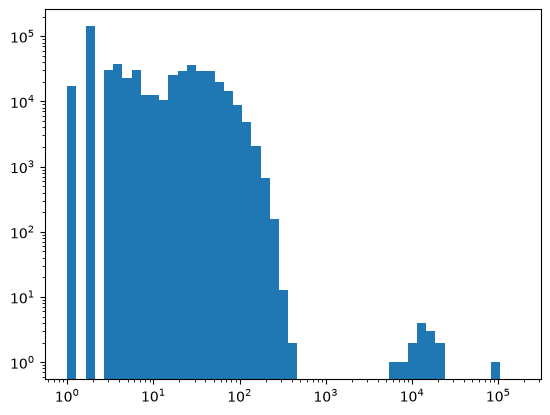

In [461]:
plt.hist(grados.values, bins=np.logspace(0, np.log10(grados.max()), 50))
plt.xscale('log')
plt.yscale('log')

In [462]:
print(grados.head(20))

100428660    169756
1004286A8    103671
100428978     20647
1004286F0     18771
100428780     17381
1004289C0     16926
100428810     16540
1004287C8     14277
100428738     13854
100428A51     13101
1004288A0     12420
100428858     11083
1004288E8      9519
100428A08      8337
100428930      6468
800058B80       394
80006FCE0       386
800058920       331
8000B8AB0       312
8015EEE90       308
Name: count, dtype: int64


In [463]:
top15 = grados.head(15).index
print(df[df['Account'].isin(top15)]['From Bank'].value_counts())

From Bank
70    449859
Name: count, dtype: int64


In [464]:
print(df[df['Account'].isin(top15)]['Is Laundering'].mean())

0.0014071075603689157


In [465]:
cuentas

0           8000EBD30
1           8000F4580
2           8000F4670
3           8000F5030
4           8000F5200
              ...    
10156685    8148A8711
10156686    8148A8711
10156687    8148A8711
10156688    8148A8711
10156689    8148A8711
Length: 10156690, dtype: str

In [466]:
unicas = cuentas.unique()
mapeo = {}
for i, cuenta in enumerate(unicas):
    mapeo[cuenta] = i




In [467]:

print(len(mapeo))
print(mapeo['8000EBD30'])

515080
0


In [468]:
df_dev = df.iloc[::10].reset_index(drop=True)
df_dev

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,ratio,Cambio_Div,amount_usd
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,US Dollar,3697.340000,US Dollar,Reinvestment,0,1.0,False,3697.340000
1,2022/09/01 00:04,1,8000F4510,11813,8011305D0,9.820000,US Dollar,9.820000,US Dollar,Credit Card,0,1.0,False,9.820000
2,2022/09/01 00:28,1420,8005F2D30,1420,8005F2D30,8163.850000,US Dollar,8163.850000,US Dollar,Reinvestment,0,1.0,False,8163.850000
3,2022/09/01 00:12,10,8006AF500,10,8006AF500,956.430000,US Dollar,956.430000,US Dollar,Reinvestment,0,1.0,False,956.430000
4,2022/09/01 00:29,10,80005D5C0,1674,800AC8E30,29382.000000,US Dollar,29382.000000,US Dollar,Cheque,0,1.0,False,29382.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507830,2022/09/10 23:46,152627,813B1E3E1,153827,813E3BDC1,0.012228,Bitcoin,0.012228,Bitcoin,Bitcoin,0,1.0,False,145.288488
507831,2022/09/10 23:32,70,100428A51,254595,814152B61,0.002278,Bitcoin,0.002278,Bitcoin,Bitcoin,0,1.0,False,27.066338
507832,2022/09/10 23:30,153827,8140ABC41,154477,8142B7F51,0.068300,Bitcoin,0.068300,Bitcoin,Bitcoin,0,1.0,False,811.514862
507833,2022/09/10 23:52,154148,81411B121,15,81474CC81,0.006058,Bitcoin,0.006058,Bitcoin,Bitcoin,0,1.0,False,71.978873


In [469]:
print(df_dev['Is Laundering'].sum())

486


In [470]:
cuentas = pd.concat([df_dev['Account'], df_dev['Account.1']], ignore_index=True)
grados = cuentas.value_counts()
print(grados.describe())

count    268588.000000
mean          3.781517
std          39.941171
min           1.000000
25%           1.000000
50%           3.000000
75%           5.000000
max       17069.000000
Name: count, dtype: float64


In [471]:
unicas = cuentas.unique()
mapeo = {}
for i, cuenta in enumerate(unicas):
    mapeo[cuenta] = i

In [472]:
origen = df_dev['Account'].map(mapeo)
destino = df_dev['Account.1'].map(mapeo)

origen

0              0
1              1
2              2
3              3
4              4
           ...  
507830     30795
507831     30792
507832    124891
507833     98602
507834    171829
Name: Account, Length: 507835, dtype: int64

In [473]:
print(origen.isna().sum())
print(destino.isna().sum())

0
0


In [474]:
edge_index = np.vstack([origen, destino])

print(edge_index.min(), edge_index.max())

0 268587


In [475]:
df_dev['Is Laundering'].sum()

np.int64(486)

In [476]:
laund = df_dev['Is Laundering'].to_numpy()

In [477]:
df_dev['Timestamp'] = pd.to_datetime(df_dev['Timestamp'], format='%Y/%m/%d %H:%M')

df_ord = df_dev.sort_values('Timestamp').reset_index(drop=True)

df_ord

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,ratio,Cambio_Div,amount_usd
0,2022-09-01 00:00:00,17400,806A55530,17400,806A55530,4.98,US Dollar,4.98,US Dollar,Reinvestment,0,1.000000,False,4.980000
1,2022-09-01 00:00:00,11318,80DD11120,11318,80DD11120,6814.60,US Dollar,6814.60,US Dollar,Reinvestment,0,1.000000,False,6814.600000
2,2022-09-01 00:00:00,231004,80B6EA960,231004,80B6EA960,944.20,US Dollar,944.20,US Dollar,Reinvestment,0,1.000000,False,944.200000
3,2022-09-01 00:00:00,15863,805266F30,15863,805266F30,19.39,Euro,19.39,Euro,Reinvestment,0,1.000000,False,22.720881
4,2022-09-01 00:00:00,218885,808F82D20,218885,808F82D20,402.95,US Dollar,402.95,US Dollar,Reinvestment,0,1.000000,False,402.950000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507830,2022-09-16 15:35:00,28,8000B8AB0,28,8000B8AB0,880.31,US Dollar,18612.53,Mexican Peso,ACH,0,0.047297,True,880.312262
507831,2022-09-17 09:39:00,118,811B6E170,119,811DCA9B0,13001.02,Saudi Riyal,13001.02,Saudi Riyal,ACH,1,1.000000,False,3465.922001
507832,2022-09-17 12:04:00,213952,80794B6F0,12513,80B3686E0,8232.86,Euro,8232.86,Euro,ACH,1,1.000000,False,9647.129105
507833,2022-09-18 01:18:00,29404,8041A3440,4403,80EA96640,6952.00,US Dollar,6952.00,US Dollar,ACH,1,1.000000,False,6952.000000


In [478]:
cuentas = pd.concat([df_ord['Account'], df_ord['Account.1']], ignore_index=True)
grados = cuentas.value_counts()

In [479]:
unicas = cuentas.unique()
mapeo = {}
for i, cuenta in enumerate(unicas):
    mapeo[cuenta] = i

In [480]:
origen = df_ord['Account'].map(mapeo)
destino = df_ord['Account.1'].map(mapeo)

edge_index = np.vstack([origen, destino]).astype(int)

edge_index

array([[     0,      1,      2, ..., 113992, 171829, 102293],
       [     0,      1,      2, ..., 234703, 266894, 123605]],
      shape=(2, 507835))

In [481]:
y = df_ord['Is Laundering'].to_numpy()
y

array([0, 0, 0, ..., 1, 1, 1], shape=(507835,))

In [482]:
print(origen.isna().sum())
print(destino.isna().sum())

0
0


In [483]:
n = len(df_ord)
c1 = int(n * 0.6)
c2 = int(n * 0.8)

split = np.zeros(n, dtype=int)
split[c1:c2] = 1
split[c2:] = 2

In [484]:
print(np.bincount(split))

for s, nombre in [(0, 'train'), (1, 'val'), (2, 'test')]:
    print(nombre, (split == s).sum(), 'ilícitas:', y[split == s].sum())

[304701 101567 101567]
train 304701 ilícitas: 213
val 101567 ilícitas: 95
test 101567 ilícitas: 178


In [485]:
f_importe = np.log1p(df_ord['amount_usd'])
print(f_importe.min(), f_importe.max())

9.487216763183026e-05 22.75349007289547


In [487]:
f_hora = df_ord['Timestamp'].dt.hour / 23
f_dia = df_ord['Timestamp'].dt.dayofweek / 6

In [488]:
edge_attr = np.column_stack([f_importe, f_tiempo, f_hora, f_dia])
print(edge_attr.shape)
print(edge_attr)

(507835, 4)
[[1.78842057 0.         0.         0.5       ]
 [8.82696938 0.         0.         0.5       ]
 [6.85139655 0.         0.         0.5       ]
 ...
 [9.1745193  0.94745236 0.52173913 0.83333333]
 [8.8469285  0.97910852 0.04347826 1.        ]
 [8.22954845 1.         0.43478261 1.        ]]


In [489]:
df_train = df_ord[split == 0]

In [490]:
cuentas_or = df_train.groupby(df_train['Account'])['amount_usd'].agg(['count', 'sum'])
print(cuentas_or.shape)

(146667, 2)


In [491]:
print(cuentas_or.head())

           count           sum
Account                       
100428660   9351  3.590392e+09
1004286A8   5665  2.334021e+09
1004286F0   1043  2.607355e+08
100428738    769  1.182654e+08
100428780    976  2.632941e+08


In [492]:
cuentas_de = df_train.groupby(df_train['Account.1'])['amount_usd'].agg(['count', 'sum'])
print(cuentas_de.shape)

(179763, 2)


In [493]:
n_cuentas = len(mapeo)
x = np.zeros((n_cuentas, 4), dtype=np.float32)

# Salidas
pos_out = cuentas_or.index.map(mapeo)
x[pos_out, 0] = cuentas_or['count'].values
x[pos_out, 1] = np.log1p(cuentas_or['sum'].values)

# Entradas
pos_in = cuentas_de.index.map(mapeo)
x[pos_in, 2] = cuentas_de['count'].values
x[pos_in, 3] = np.log1p(cuentas_de['sum'].values)

print(x.shape)
print(x[:5])

(268588, 4)
[[1.        1.7884206 1.        1.7884206]
 [1.        8.826969  1.        8.826969 ]
 [3.        7.067263  1.        6.8513966]
 [3.        8.983131  4.        8.749068 ]
 [1.        6.0012913 1.        6.0012913]]


In [494]:
print("¿Col 0 == Col 2?", np.array_equal(x[:, 0], x[:, 2]))   # debe dar False
print("Sin NaN:", np.isnan(x).sum() == 0)                      # debe dar True
print("Cuentas con salidas:", (x[:, 0] > 0).sum())             # ≈ 146.667
print("Cuentas con entradas:", (x[:, 2] > 0).sum())            # ≈ 179.763

¿Col 0 == Col 2? False
Sin NaN: True
Cuentas con salidas: 146667
Cuentas con entradas: 179763


In [495]:
print(len(mapeo))
print(edge_index.max())

268588
268587


In [496]:
import torch
from torch_geometric.data import Data

data = Data(
    x=torch.tensor(x, dtype=torch.float),
    edge_index=torch.tensor(edge_index, dtype=torch.long),
    edge_attr=torch.tensor(edge_attr, dtype=torch.float),
    y=torch.tensor(y, dtype=torch.long),
)
data.split = torch.tensor(split, dtype=torch.long)

print(data)

Data(x=[268588, 4], edge_index=[2, 507835], edge_attr=[507835, 4], y=[507835], split=[507835])


In [497]:
torch.save(data, ROOT / 'data' / 'processed' / 'amlworld_dev.pt')